In [ ]:
pip install iterative-stratification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_excel('full_agumented_data_clean.xlsx')

In [ ]:
df.shape

(12550, 22)

### Split the datasets based on each labels

In [ ]:
maps = ['bathroom-atmosphere', 'bathroom-cleanliness',
       'bathroom-facilities', 'bathroom-general', 'bed-cleanliness',
       'bed-general', 'catering-general', 'catering-price', 'hotel-atmosphere',
       'hotel-cleanliness', 'hotel-facilities', 'hotel-general',
       'hotel-location', 'hotel-price', 'parking', 'room-atmosphere',
       'room-cleanliness', 'room-facilities', 'room-general', 'staff']

In [ ]:
X = df['type'].values
y = df[maps].values  # all topic columns as the multi-label target

msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in msss.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 10060, Test size: 2490


The proportions of each topic should be nearly identical between train and test. Verify the split preserved topic distribution:

In [ ]:
train_df = pd.DataFrame(y_train, columns=maps)
test_df = pd.DataFrame(y_test, columns=maps)

print('Train distribution:')
print(train_df.sum() / len(train_df))

print('\nTest distribution:')
print(test_df.sum() / len(test_df))

Train distribution:
bathroom-atmosphere     0.032306
bathroom-cleanliness    0.031213
bathroom-facilities     0.082903
bathroom-general        0.019483
bed-cleanliness         0.016103
bed-general             0.119881
catering-general        0.148509
catering-price          0.027833
hotel-atmosphere        0.165805
hotel-cleanliness       0.077237
hotel-facilities        0.113519
hotel-general           0.131412
hotel-location          0.291054
hotel-price             0.082903
parking                 0.032803
room-atmosphere         0.222068
room-cleanliness        0.079920
room-facilities         0.166402
room-general            0.071571
staff                   0.357853
dtype: float64

Test distribution:
bathroom-atmosphere     0.032530
bathroom-cleanliness    0.031325
bathroom-facilities     0.083936
bathroom-general        0.019679
bed-cleanliness         0.016466
bed-general             0.120884
catering-general        0.149799
catering-price          0.028112
hotel-atmosphere     

In total, 80% of data (7153) are splited to the training set and the rest (1831) is to the test set.

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10060,), (10060, 20), (2490,), (2490, 20))

### Text Categorization Pipeline


# Transformers

In [ ]:
# 1. Installing and Loading Packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


model_name = "bert-base-multilingual-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# =============================================================================
# 2. Data re-segmentation
# =============================================================================
# Split the original X_train into 80% for training and 20% for validation.
X_sub_train, X_val, y_sub_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"train set (80%): {len(X_sub_train)}")
print(f"validation set (20%): {len(X_val)}")
print(f"test set : {len(X_test)}")

# Convert the data into Hugging Face Dataset format (three datasets).
train_ds = Dataset.from_dict({"text": X_sub_train.tolist(), "label": y_sub_train.astype(float)})
val_ds = Dataset.from_dict({"text": X_val.tolist(), "label": y_val.astype(float)})
test_ds = Dataset.from_dict({"text": X_test.tolist(), "label": y_test.astype(float)})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_ds.map(tokenize_function, batched=True)
val_dataset = val_ds.map(tokenize_function, batched=True)
test_dataset = test_ds.map(tokenize_function, batched=True)

# =============================================================================
# 3. Define model and training parameters
# =============================================================================
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=20,
    problem_type="multi_label_classification"
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    eval_strategy="epoch",           # Run an evaluation on the “validation set” at the end of every epoch.
    save_strategy="epoch",           # The storage strategy must be consistent with the evaluation strategy.
    load_best_model_at_end=True,     # After training, automatically load the weights that performed best on the validation set.
    metric_for_best_model="loss",    # The model with the lowest validation loss shall prevail.
    weight_decay=0.01,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)


trainer.train()


print("\n--- mBERT Final Classification Report (Blind Test Set X_test) ---")

# Get the predicted value
output = trainer.predict(test_dataset)
probs = torch.sigmoid(torch.from_numpy(output.predictions)).numpy()

# Convert to 0/1 using 0.5 as the threshold.
y_pred_bert = (probs > 0.5).astype(int)

# Produce report
print(classification_report(y_test, y_pred_bert, target_names=maps, zero_division=0))

train set (80%): 8048
validation set (20%): 2012
test set : 2490


Map:   0%|          | 0/8048 [00:00<?, ? examples/s]

Map:   0%|          | 0/2012 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


--- mBERT Final Classification Report (Blind Test Set X_test) ---


                      precision    recall  f1-score   support

 bathroom-atmosphere       0.79      0.46      0.58        81
bathroom-cleanliness       0.84      0.67      0.74        78
 bathroom-facilities       0.86      0.83      0.85       209
    bathroom-general       0.82      0.37      0.51        49
     bed-cleanliness       0.64      0.17      0.27        41
         bed-general       0.95      0.97      0.96       301
    catering-general       0.93      0.94      0.93       373
      catering-price       0.89      0.59      0.71        70
    hotel-atmosphere       0.91      0.89      0.90       417
   hotel-cleanliness       0.93      0.92      0.93       194
    hotel-facilities       0.92      0.87      0.89       286
       hotel-general       0.95      0.86      0.90       331
      hotel-location       0.99      0.98      0.99       732
         hotel-price       0.92      0.90      0.91       209
             parking       0.92      0.95      0.93        83
     ro

# save model

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# drive_save_path = "/content/drive/MyDrive/NLP-share task/best_model"

# trainer.save_model(drive_save_path)
# tokenizer.save_pretrained(drive_save_path)
# print("The model has been safely saved to Google Drive and will not disappear when Colab is closed.。")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# from transformers import AutoModelForSequenceClassification

# final_model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/NLP-share task__test/best_model")

Mounted at /content/drive


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:

# !pip install huggingface_hub transformers


# from huggingface_hub import notebook_login
# notebook_login()

In [ ]:

# repo_id = "Hailey97/best_model"

# model.push_to_hub(repo_id)
# tokenizer.push_to_hub(repo_id)

# print(f"✅ The model has been successfully uploaded to ：https://huggingface.co/{repo_id}")

# Error analysis

In [ ]:
def error_analysis(y_test_arr, y_pred, maps, save_path='confusion_matrices.png'):
    """
    Generate per-label confusion matrices and aggregate error summary.
    """
    n_labels = y_test_arr.shape[1]
    n_cols   = 4
    n_rows   = int(np.ceil(n_labels / n_cols))

    # --- Confusion Matrix Heatmaps ---
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
    axes      = axes.flatten()

    for i in range(n_labels):
        cm = confusion_matrix(y_test_arr[:, i], y_pred[:, i])
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i],
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
            cbar=False
        )
        axes[i].set_title(f'{maps[i]}', fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Predicted', fontsize=7)
        axes[i].set_ylabel('Actual', fontsize=7)

    for j in range(n_labels, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Per-Label Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrices saved as: {save_path}")

    # --- Aggregate Summary Table ---
    print("\n===================================================")
    print("ERROR ANALYSIS — AGGREGATE LABEL SUMMARY")
    print("===================================================")

    summary = []
    for i in range(n_labels):
        cm = confusion_matrix(y_test_arr[:, i], y_pred[:, i])
        tn = cm[0, 0] if cm.shape == (2, 2) else 0
        fp = cm[0, 1] if cm.shape == (2, 2) else 0
        fn = cm[1, 0] if cm.shape == (2, 2) else 0
        tp = cm[1, 1] if cm.shape == (2, 2) else 0

        summary.append({
            'Label'    : maps[i],
            'TP'       : tp,
            'FP'       : fp,
            'FN'       : fn,
            'TN'       : tn,
            'Precision': round(tp / (tp + fp) if (tp + fp) > 0 else 0, 3),
            'Recall'   : round(tp / (tp + fn) if (tp + fn) > 0 else 0, 3),
            'F1'       : round(2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0, 3)
        })

    print(f"{'Label':<20} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print("-" * 72)
    for row in summary:
        print(f"{row['Label']:<20} {row['TP']:>6} {row['FP']:>6} {row['FN']:>6} {row['TN']:>6} {row['Precision']:>8} {row['Recall']:>8} {row['F1']:>8}")

    # --- Most Confused Labels ---
    print("\n===================================================")
    print("MOST CONFUSED LABELS")
    print("===================================================")
    for row in sorted(summary, key=lambda x: x['FP'] + x['FN'], reverse=True)[:5]:
        print(f"Label: {row['Label']:<20} FP: {row['FP']:>5}  FN: {row['FN']:>5}  F1: {row['F1']:>6}")

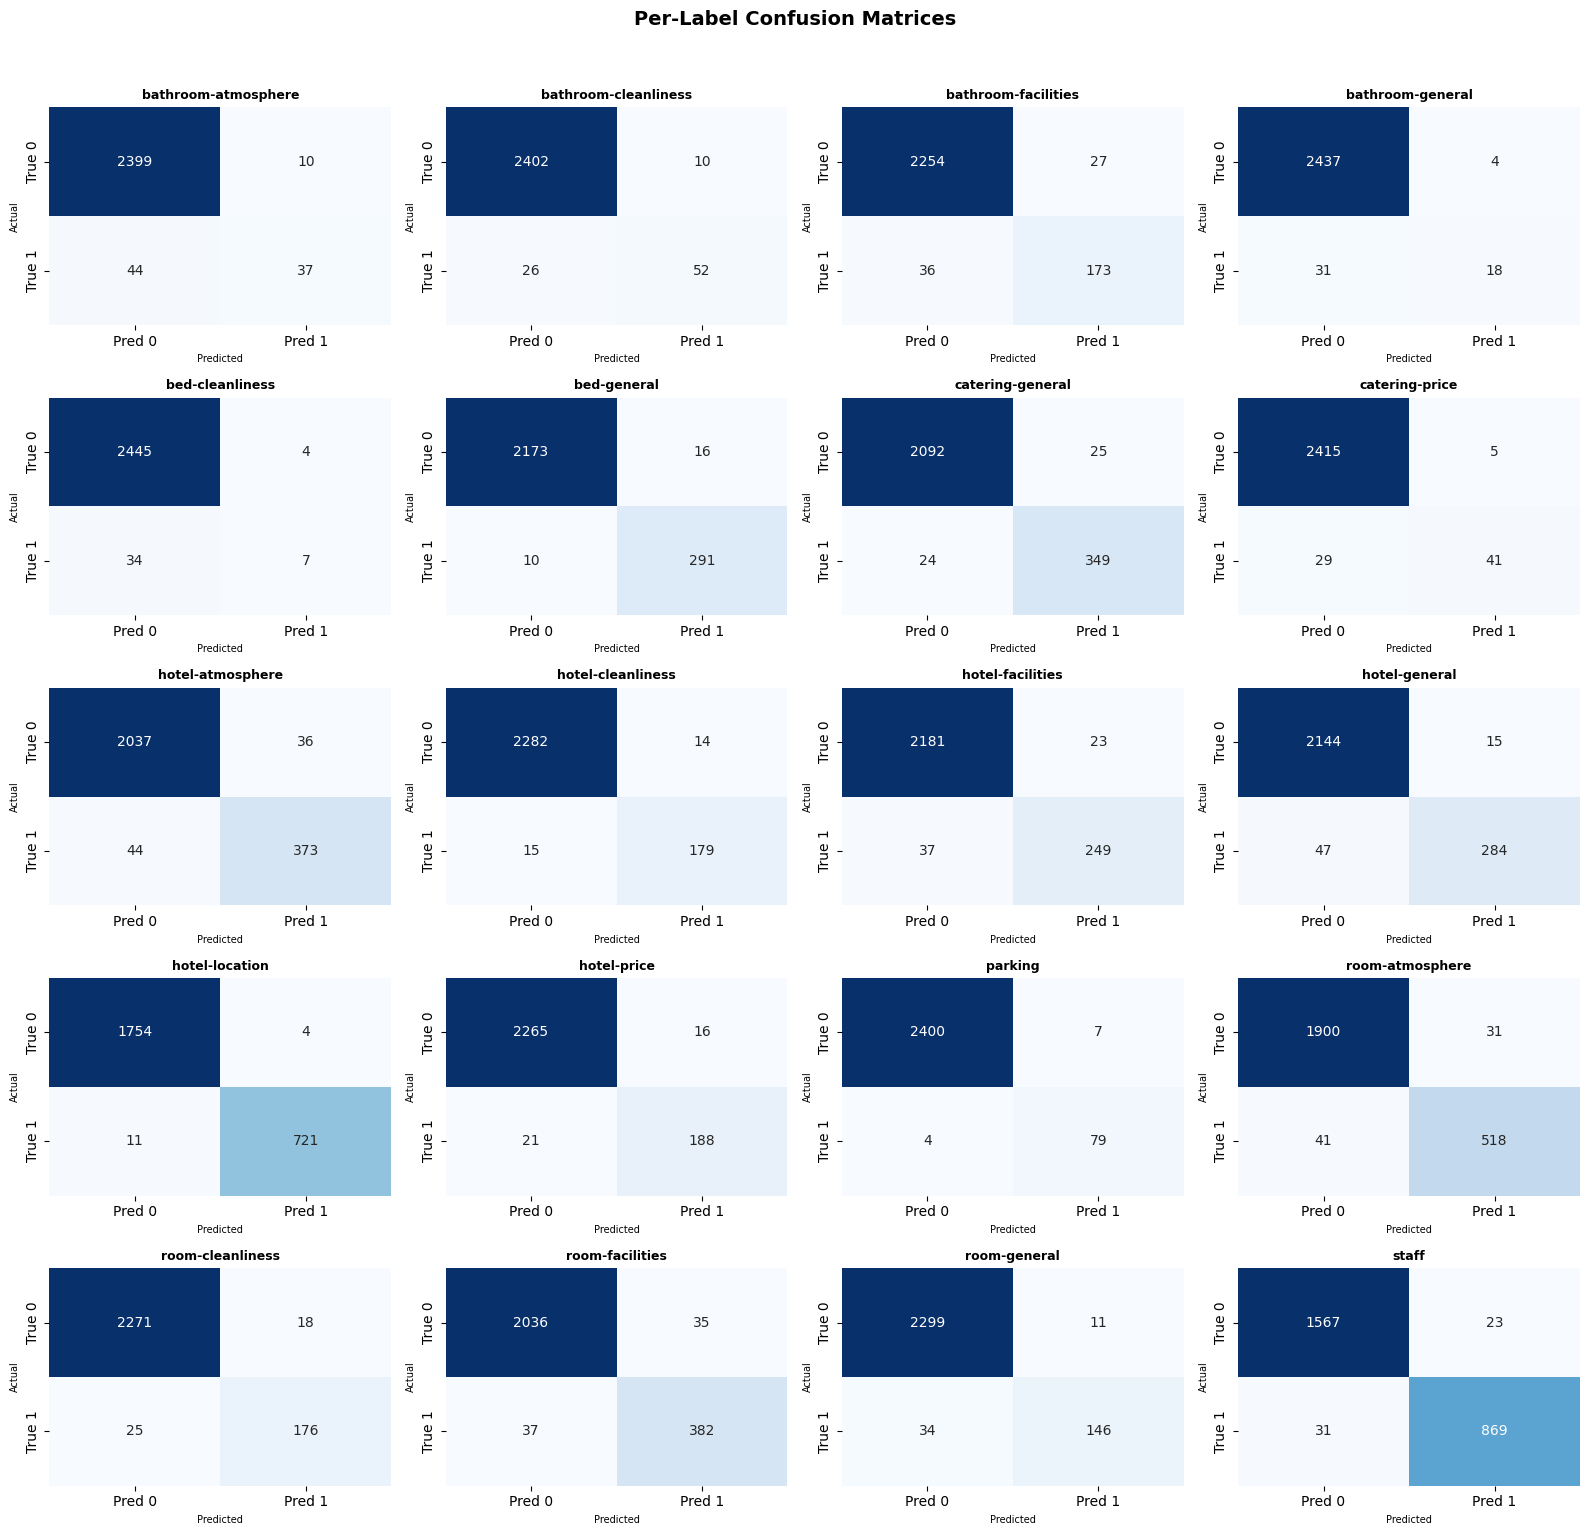

Confusion matrices saved as: mbert_error_analysis.png

ERROR ANALYSIS — AGGREGATE LABEL SUMMARY
Label                    TP     FP     FN     TN     Prec      Rec       F1
------------------------------------------------------------------------
bathroom-atmosphere      37     10     44   2399    0.787    0.457    0.578
bathroom-cleanliness     52     10     26   2402    0.839    0.667    0.743
bathroom-facilities     173     27     36   2254    0.865    0.828    0.846
bathroom-general         18      4     31   2437    0.818    0.367    0.507
bed-cleanliness           7      4     34   2445    0.636    0.171    0.269
bed-general             291     16     10   2173    0.948    0.967    0.957
catering-general        349     25     24   2092    0.933    0.936    0.934
catering-price           41      5     29   2415    0.891    0.586    0.707
hotel-atmosphere        373     36     44   2037    0.912    0.894    0.903
hotel-cleanliness       179     14     15   2282    0.927    0.923    0

In [ ]:

y_test_arr = y_test.toarray() if hasattr(y_test, 'toarray') else np.array(y_test)


error_analysis(y_test_arr, y_pred_bert, maps, save_path='mbert_error_analysis.png')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_multilabel_global_matrix(y_true, y_pred, labels, normalize=True):

    n_labels = len(labels)

    matrix = np.zeros((n_labels, n_labels))

    for i in range(len(y_true)):
        true_indices = np.where(y_true[i] == 1)[0]
        pred_indices = np.where(y_pred[i] == 1)[0]

        for t in true_indices:
            for p in pred_indices:
                matrix[t, p] += 1

    raw_matrix = matrix.copy()  # Save raw counts before normalization

    if normalize:
        row_sums = matrix.sum(axis=1)
        matrix = np.divide(matrix, row_sums[:, np.newaxis], out=np.zeros_like(matrix), where=row_sums[:, np.newaxis]!=0)

    plt.figure(figsize=(14, 12))

    # Build annotation array showing both % and count
    annot_labels = np.empty(matrix.shape, dtype=object)
    for i in range(n_labels):
        for j in range(n_labels):
            count = int(raw_matrix[i, j])
            if normalize:
                pct = matrix[i, j] * 100
                if count > 0:
                    annot_labels[i, j] = f"{pct:.1f}%\n({count})"
                else:
                    annot_labels[i, j] = ""
            else:
                annot_labels[i, j] = str(count) if count > 0 else ""

    sns.heatmap(matrix,
                annot=annot_labels,
                fmt="",                 # Required when annot contains strings
                annot_kws={"size": 7},  # Adjust font size to fit cells
                cmap='viridis',
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=0.3)

    plt.title('Bert-base-multilingual-uncased', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')

    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig('Bert-base-multilingual-uncased.png', dpi=300)
    plt.show()
    print("Bert-base-multilingual-uncased.png")




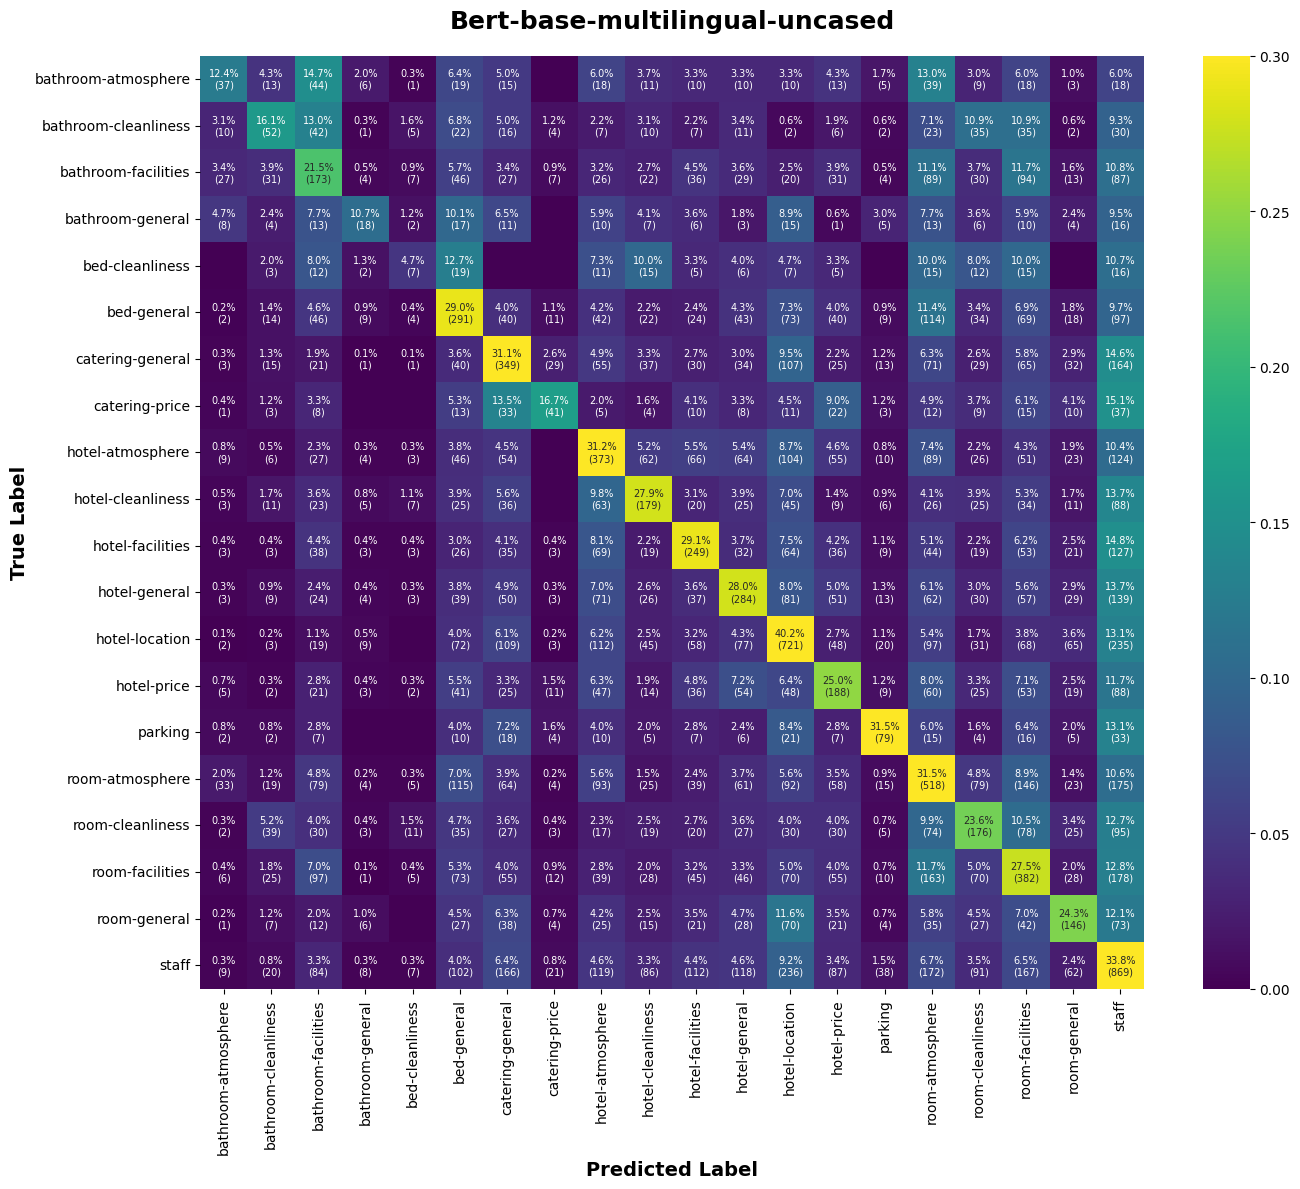

Bert-base-multilingual-uncased.png


In [ ]:
plot_multilabel_global_matrix(y_test, y_pred_bert, maps, normalize=True)